# 02 · Exploratory Data Analysis
Goals distributions, home advantage, confederation strengths, WC-specific patterns.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import poisson
from src.data_loader import load_all
np.random.seed(42)

PLOT_DIR = '../outputs/plots'
os.makedirs(PLOT_DIR, exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
data = load_all(verbose=False)
results = data['results_primary']
registry = data['team_registry']


INFO | Loading results from /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/raw/results.csv
INFO |   Raw rows: 49,477
WARNING |   Found 2 duplicate match entries — dropping
INFO |   Full dataset: 49,475 rows | Primary (1990+): 32,358
INFO | former_names.csv columns: ['current', 'former', 'start_date', 'end_date']
INFO | Loaded 42 former name mappings
INFO | Loaded group fixtures: 72 matches, groups ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
INFO | Loaded knockout slots: 32 matches
INFO | Loaded FIFA rankings for 48 teams
INFO | Loaded WC historical stats: 964 matches (1930-2022)
INFO | Saved team_registry.csv: 48 teams → /Users/saurabhgupta/Desktop/ml_projects/fifa-wc-2026-prediction/data/processed/team_registry.csv


## 2.1 Goals Distribution Analysis

INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


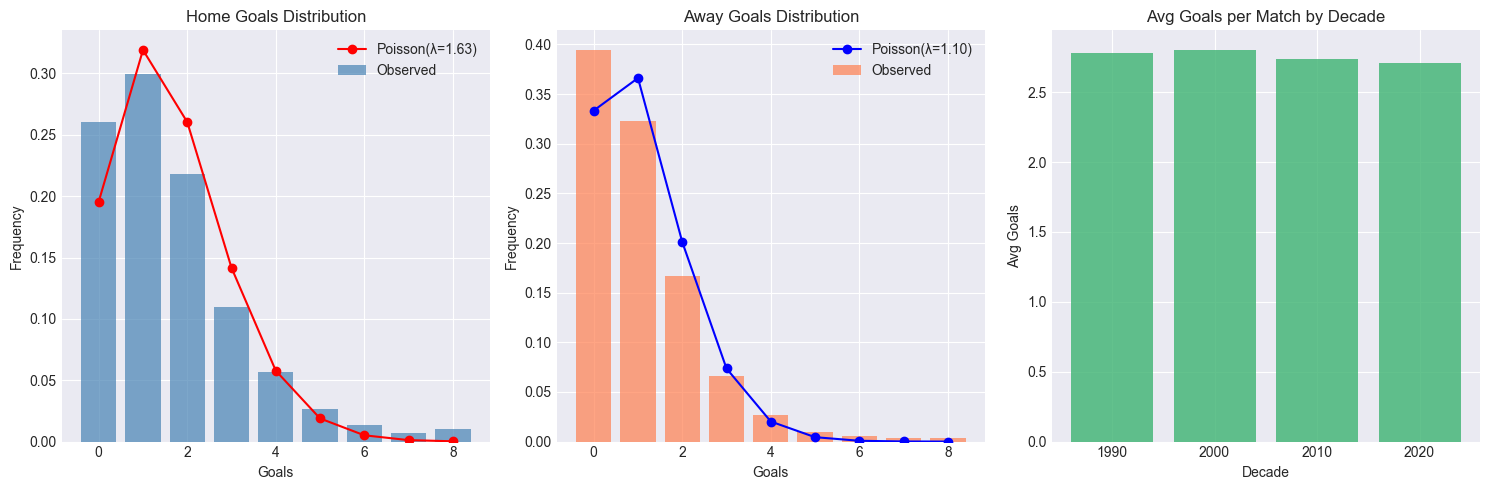

Home goals — Mean: 1.632, Var: 2.528
Away goals — Mean: 1.098, Var: 1.651
Total goals — Mean: 2.761, Var: 3.958
Overdispersion index (var/mean): 1.434


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Home goals
home_goals = results['home_score'].clip(0, 8)
x = np.arange(0, 9)
lam_h = home_goals.mean()
axes[0].bar(x, np.bincount(home_goals, minlength=9)/len(home_goals),
            alpha=0.7, label='Observed', color='steelblue')
axes[0].plot(x, poisson.pmf(x, lam_h), 'r-o', ms=6, label=f'Poisson(λ={lam_h:.2f})')
axes[0].set(title='Home Goals Distribution', xlabel='Goals', ylabel='Frequency')
axes[0].legend()

# Away goals
away_goals = results['away_score'].clip(0, 8)
lam_a = away_goals.mean()
axes[1].bar(x, np.bincount(away_goals, minlength=9)/len(away_goals),
            alpha=0.7, label='Observed', color='coral')
axes[1].plot(x, poisson.pmf(x, lam_a), 'b-o', ms=6, label=f'Poisson(λ={lam_a:.2f})')
axes[1].set(title='Away Goals Distribution', xlabel='Goals', ylabel='Frequency')
axes[1].legend()

# Total goals over time
results['decade'] = (results['date'].dt.year // 10) * 10
decade_goals = results.groupby('decade').apply(
    lambda df: (df['home_score'] + df['away_score']).mean()).reset_index()
decade_goals.columns = ['decade', 'avg_goals']
axes[2].bar(decade_goals['decade'].astype(str), decade_goals['avg_goals'],
            color='mediumseagreen', alpha=0.8)
axes[2].set(title='Avg Goals per Match by Decade', xlabel='Decade', ylabel='Avg Goals')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/goals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Home goals — Mean: {lam_h:.3f}, Var: {home_goals.var():.3f}")
print(f"Away goals — Mean: {lam_a:.3f}, Var: {away_goals.var():.3f}")
total = results['home_score'] + results['away_score']
print(f"Total goals — Mean: {total.mean():.3f}, Var: {total.var():.3f}")
print(f"Overdispersion index (var/mean): {total.var()/total.mean():.3f}")


## 2.2 Home Advantage Analysis

Home Advantage by Venue Type:
    neutral  n_matches  home_win_pct  draw_pct  away_win_pct
Non-Neutral    23186.0      0.507461  0.234711      0.257699
    Neutral     9172.0      0.426297  0.235717      0.335696


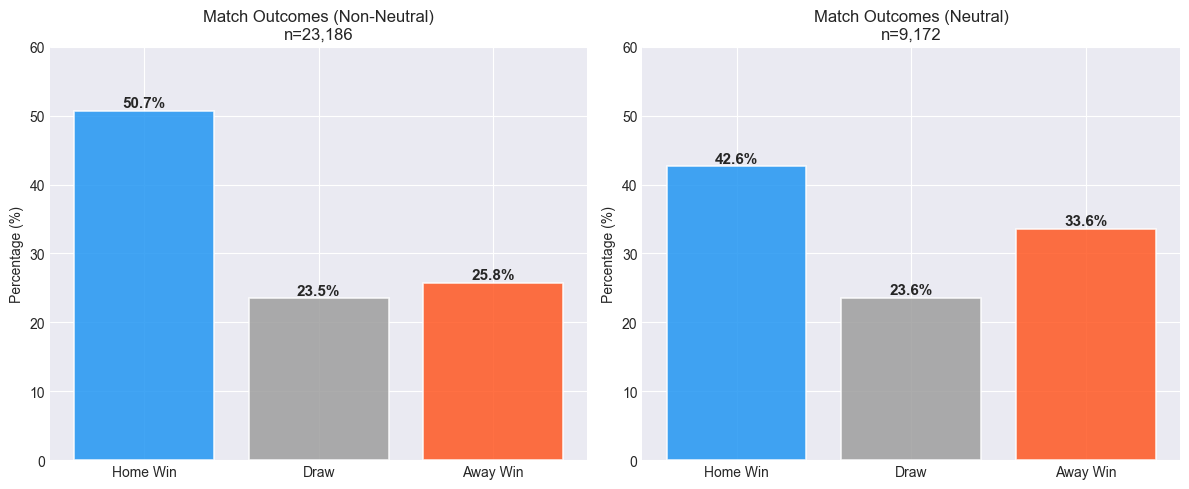


⚠️  Note: 2026 WC = neutral venue for all (non-host) teams → use neutral stats


In [3]:
home_adv = results.groupby('neutral').apply(lambda df: pd.Series({
    'n_matches': len(df),
    'home_win_pct': (df['home_score'] > df['away_score']).mean(),
    'draw_pct': (df['home_score'] == df['away_score']).mean(),
    'away_win_pct': (df['home_score'] < df['away_score']).mean(),
})).reset_index()
home_adv['neutral'] = home_adv['neutral'].map({True: 'Neutral', False: 'Non-Neutral'})
print("Home Advantage by Venue Type:")
print(home_adv.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
outcomes = ['home_win_pct', 'draw_pct', 'away_win_pct']
colors = ['#2196F3', '#9E9E9E', '#FF5722']
labels = ['Home Win', 'Draw', 'Away Win']

for i, row in home_adv.iterrows():
    ax = axes[i]
    vals = [row[o]*100 for o in outcomes]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set(title=f"Match Outcomes ({row['neutral']})\nn={int(row['n_matches']):,}", 
           ylabel='Percentage (%)', ylim=(0, 60))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/home_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️  Note: 2026 WC = neutral venue for all (non-host) teams → use neutral stats")


## 2.3 Confederation Strength Analysis

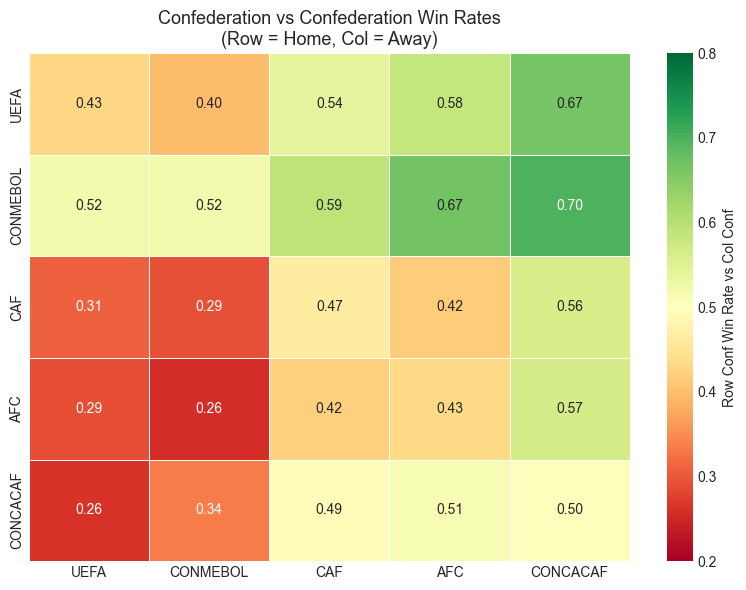

In [4]:
from src.data_loader import CONFEDERATION_MAP
results['conf_home'] = results['home_team'].map(CONFEDERATION_MAP).fillna('Other')
results['conf_away'] = results['away_team'].map(CONFEDERATION_MAP).fillna('Other')

main_confs = ['UEFA', 'CONMEBOL', 'CAF', 'AFC', 'CONCACAF']
conf_results = results[results['conf_home'].isin(main_confs) & 
                        results['conf_away'].isin(main_confs)]

matrix = {}
for ch in main_confs:
    matrix[ch] = {}
    for ca in main_confs:
        sub = conf_results[(conf_results['conf_home']==ch) & (conf_results['conf_away']==ca)]
        if len(sub) >= 20:
            matrix[ch][ca] = round((sub['home_score'] > sub['away_score']).mean(), 3)
        else:
            matrix[ch][ca] = np.nan

conf_df = pd.DataFrame(matrix).T.loc[main_confs, main_confs]
plt.figure(figsize=(8, 6))
sns.heatmap(conf_df, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            linewidths=0.5, vmin=0.2, vmax=0.8,
            cbar_kws={'label': 'Row Conf Win Rate vs Col Conf'})
plt.title('Confederation vs Confederation Win Rates\n(Row = Home, Col = Away)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/confederation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.4 World Cup Specific Patterns

Total WC matches in dataset: 7,601
WC date range: 1990-06-08 → 2026-06-27

Group stage matches:  7,601
Knockout matches:      0


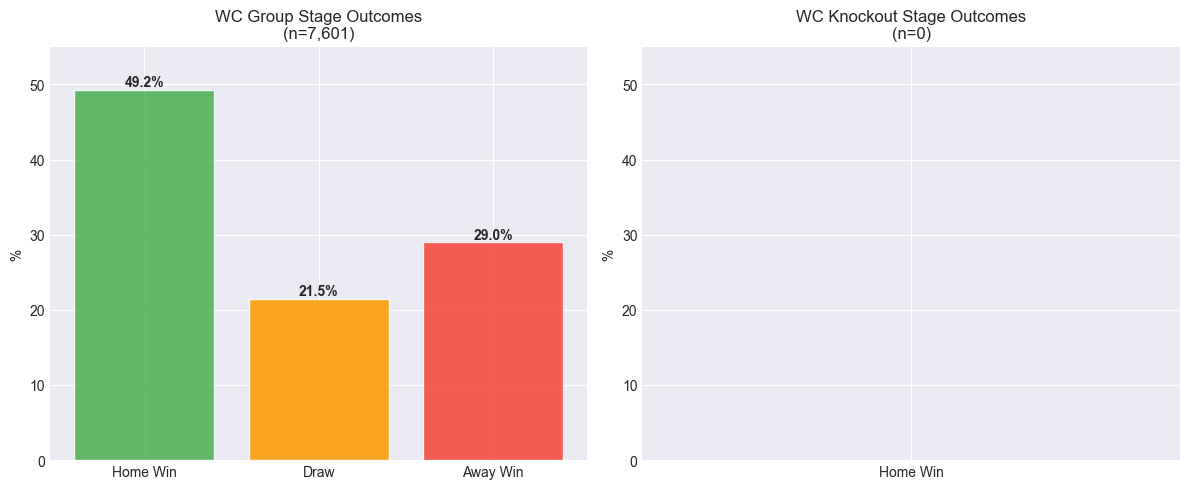


Group stage draw rate: nan%
Knockout stage draw rate (ties = 90-min draws): nan%


In [5]:
wc_matches = results[results['is_wc'] == True].copy()
print(f"Total WC matches in dataset: {len(wc_matches):,}")
print(f"WC date range: {wc_matches['date'].min().date()} → {wc_matches['date'].max().date()}")

wc_group = wc_matches[~wc_matches['is_knockout']]
wc_ko    = wc_matches[wc_matches['is_knockout']]

print(f"\nGroup stage matches:  {len(wc_group):,}")
print(f"Knockout matches:      {len(wc_ko):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, df, title in [(axes[0], wc_group, 'Group Stage'), (axes[1], wc_ko, 'Knockout Stage')]:
    hw = (df['home_score'] > df['away_score']).mean()
    d  = (df['home_score'] == df['away_score']).mean()
    aw = (df['home_score'] < df['away_score']).mean()
    bars = ax.bar(['Home Win', 'Draw', 'Away Win'], [hw*100, d*100, aw*100],
                  color=['#4CAF50','#FF9800','#F44336'], alpha=0.85, edgecolor='white')
    ax.set(title=f'WC {title} Outcomes\n(n={len(df):,})', ylabel='%', ylim=(0, 55))
    for bar, val in zip(bars, [hw, d, aw]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/wc_stage_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGroup stage draw rate: {d:.1%}")
print(f"Knockout stage draw rate (ties = 90-min draws): {(wc_ko['home_score'] == wc_ko['away_score']).mean():.1%}")


## 2.5 Team Profiles for WC 2026 Teams

In [6]:
wc_teams = sorted(set(registry['team_name']))
profiles = []

for team in wc_teams:
    team_matches = results[
        (results['home_team'] == team) | (results['away_team'] == team)
    ].tail(20)
    
    if len(team_matches) == 0:
        continue
    
    def compute_stats(df, t):
        wins, draws, losses, gf, ga = 0, 0, 0, 0, 0
        for _, r in df.iterrows():
            if r['home_team'] == t:
                gf += r['home_score']; ga += r['away_score']
                if r['home_score'] > r['away_score']: wins += 1
                elif r['home_score'] == r['away_score']: draws += 1
                else: losses += 1
            else:
                gf += r['away_score']; ga += r['home_score']
                if r['away_score'] > r['home_score']: wins += 1
                elif r['home_score'] == r['away_score']: draws += 1
                else: losses += 1
        n = len(df)
        return wins, draws, losses, gf/max(n,1), ga/max(n,1), n
    
    w, d, l, gf, ga, n = compute_stats(team_matches, team)
    w10, d10, l10, gf10, ga10, n10 = compute_stats(team_matches.tail(10), team)
    
    reg_row = registry[registry['team_name'] == team]
    g = reg_row['group'].iloc[0] if len(reg_row) else '?'
    fi = reg_row['fifa_ranking'].iloc[0] if len(reg_row) else 999
    fp = reg_row['fifa_points'].iloc[0] if len(reg_row) else 0
    
    profiles.append({
        'team': team, 'group': g, 'fifa_rank': fi, 'fifa_points': fp,
        'win_rate_20': round(w/max(n,1), 3), 'goals_for_avg': round(gf, 2),
        'goals_against_avg': round(ga, 2),
        'win_rate_10': round(w10/max(n10,1), 3),
        'n_recent': n,
    })

profiles_df = pd.DataFrame(profiles).sort_values('fifa_rank')
profiles_df.to_csv('../data/processed/team_profiles.csv', index=False)
print(f"Saved team_profiles.csv: {len(profiles_df)} teams")
profiles_df.head(12)


Saved team_profiles.csv: 48 teams


,team,group,fifa_rank,fifa_points,win_rate_20,goals_for_avg,goals_against_avg,win_rate_10,n_recent
1,Argentina,J,1,1876.12,0.75,NaN,NaN,0.9,20
40,Spain,H,2,1873.01,0.60,NaN,NaN,0.5,20
18,France,I,3,1869.43,0.70,NaN,NaN,0.7,20
17,England,L,4,1827.05,0.75,NaN,NaN,0.6,20
33,Portugal,K,5,1766.18,0.55,NaN,NaN,0.5,20
6,Brazil,C,6,1765.86,0.50,NaN,NaN,0.5,20
27,Morocco,C,7,1755.10,0.65,NaN,NaN,0.5,20
28,Netherlands,F,8,1751.10,0.50,NaN,NaN,0.5,20
4,Belgium,G,9,1742.24,0.45,NaN,NaN,0.5,20
19,Germany,E,10,1735.77,0.70,NaN,NaN,0.9,20


## ✅ Phase 2 Complete
Plots saved to `outputs/plots/`, team profiles saved to `data/processed/team_profiles.csv`.